In [1]:
using NeutralAtoms


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


In [2]:
include("../default.jl")
_, cfg_CZ_2gauss = get_default_configs();

ϕ = 0.0
Ω0 = cfg_CZ_2gauss.blue_laser_params["Ω"]
w = cfg_CZ_2gauss.blue_laser_params["w0"]
z = cfg_CZ_2gauss.blue_laser_params["z0"];

In [3]:
function corr_om(ϕ, d,w,z)
    E = gauss_field(0.0,0.0,0.0, w, z) + exp(1.0im*ϕ) * gauss_field(0.0,d,0.0, w, z)
    return 1/abs(E)
end;

In [4]:
cfg_CZ_2gauss.blue_laser_params["type"] = "2gauss" #"gauss" #
cfg_CZ_2gauss.blue_laser_params["Ω"] = Ω0*corr_om(ϕ,1.7+1.7,w,z)
cfg_CZ_2gauss.blue_laser_params["Ω1"] = Ω0*corr_om(ϕ,-1.7-1.7,w,z)
cfg_CZ_2gauss.blue_laser_params["w1"] = 2.0 #w; 
cfg_CZ_2gauss.blue_laser_params["z1"] = z #cfg_CZ_2gauss.blue_laser_params["z0"]; 
cfg_CZ_2gauss.blue_laser_params["rel_phase"] = ϕ
cfg_CZ_2gauss.blue_laser_params["beams_centers"] = [[0.0,1.7,0.0],[0.0,-1.7,0.0]] ;

In [5]:
@inline function Ω(x, y, z, laser_params) 
    if (laser_params["type"] == "2gauss")
        θ = laser_params["θ"]

        x1, y1, z1 = laser_params["beams_centers"][1]
        E1 = laser_params["Ω"] .* gauss_field(x.-x1, y.-y1, z.-z1, laser_params["w0"], laser_params["z0"]; θ0=θ)
        
        x2, y2, z2 = laser_params["beams_centers"][2]
        E2 = laser_params["Ω1"] .* gauss_field(x.-x2, y.-y2, z.-z2, laser_params["w1"], laser_params["z1"]; θ0=θ)

        return E1 .+ exp(1.0im * laser_params["rel_phase"]) .* E2
    else
        throw(error("Unsupported type of beam"))
    end;
end;

In [6]:
Ωr2Δ = cfg_CZ_2gauss.red_laser_params["Ω"] / (2*cfg_CZ_2gauss.detuning_params[1])

0.05307604019941166

In [7]:
ws = 1.0:0.05:2.2 #vcat(0.4:0.1:2.0, 2.5:0.5:4.0)
E2g = []
z0 = cfg_CZ_2gauss.blue_laser_params["z0"]; 
w0 = cfg_CZ_2gauss.blue_laser_params["w0"];
ϕ0 = cfg_CZ_2gauss.blue_laser_params["rel_phase"];
for w in ws
    cfg_CZ_2gauss.blue_laser_params["w0"] = w
    cfg_CZ_2gauss.blue_laser_params["w1"] = w
    cfg_CZ_2gauss.blue_laser_params["z0"] = z0*(w0/w)^2
    cfg_CZ_2gauss.blue_laser_params["z1"] = z0*(w0/w)^2
    cfg_CZ_2gauss.blue_laser_params["Ω"] = Ω0*corr_om(ϕ0, 1.7+1.7, w,z0*(w0/w)^2)
    cfg_CZ_2gauss.blue_laser_params["Ω1"] = Ω0*corr_om(ϕ0,-1.7-1.7,w,z0*(w0/w)^2)
    
    push!(E2g, Ωr2Δ * abs(Ω(3.4,1.7,0., cfg_CZ_2gauss.blue_laser_params))/ (2π*2.41))
end;

In [8]:
xx = -5.0:0.1:5.0
E = [abs(Ω(0.,x,0.,cfg_CZ_2gauss.blue_laser_params)) for x in xx];

In [10]:
using DataFrames
using CSV
using DelimitedFiles    

In [11]:
#df = CSV.File("flattop_data.dat"; header=true) |> DataFrame
df = DataFrame(readdlm("flattop_data.dat"), :auto);

ArgumentError: ArgumentError: Cannot open 'flattop_data.dat': not a file

In [12]:
corrX = -92.1
corrY = -88.7
x = df.x2 .+ corrX
y = df.x4 .+ corrY
z = 1 .- df.x6;

UndefVarError: UndefVarError: `df` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.
Hint: a global variable of this name also exists in Rmath.

In [13]:
using Statistics
z0 = sqrt.(z) .- 0.168 # 0.166
mean(vcat(z0[1:100],z0[900:end]))

MethodError: MethodError: no method matching getindex(::Float64, ::UnitRange{Int64})
The function `getindex` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  getindex(::Number, !Matched::Integer)
   @ Base number.jl:96
  getindex(::Number)
   @ Base number.jl:95
  getindex(::Number, !Matched::Integer...)
   @ Base number.jl:101
  ...


In [14]:
"""using Plots
plot(x,y,z, camera = (-10,-10), legend=false)z1 = Vector[[10*j+i*i for i in range(0,10)] for j in range(0,10)]
z_xy = Vector[[real(reconstruct_HG_field(xx[i], yy[j], 0., laser_params, a*coeffs_x, b*coeffs_y)) for i in eachindex(xx)] for j in eachindex(yy)]"""

"using Plots\nplot(x,y,z, camera = (-10,-10), legend=false)z1 = Vector[[10*j+i*i for i in range(0,10)] for j in range(0,10)]\nz_xy = Vector[[real(reconstruct_HG_field(xx[i], yy[j], 0., laser_params, a*coeffs_x, b*coeffs_y)) for i in eachindex(xx)] for j in eachindex(yy)]"

In [15]:
xx = round.(3.8*x, digits=2);
yy = round.(3.8*y, digits=2);
x_span = maximum(xx)-minimum(xx);
y_span = maximum(yy)-minimum(yy);
#z0 = z .- 0.03 #sqrt.( abs.(z0) ./ maximum(z0))
z0 = sqrt.(z) .- 0.168 #0.166
z_z = (z0) ./ maximum(z0)
#z_z = 

zz = z_z * 1.05 ; #1.02;

UndefVarError: UndefVarError: `x` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

In [16]:
len_x, len_y = 0,0
if (xx[1] == xx[31])
    len_x = 30
    len_y = 33
end;

In [17]:
using SpecialPolynomials
function HG(x, w, n)
    her_arg = zeros(n+1)
    her_arg[n+1] = 1
    Hn = Hermite(her_arg)
    #norm = 2^(n/2) * factorial(n)^0.5 * (pi/2)^(1/4)
    return exp.(-x.^2 ./ w^2) .* Hn.(2^0.5 .* x ./ w ) #./ norm
end;

In [18]:
n_max = 10 #20
m_max = n_max
dx = x_span/len_x
dy = y_span/len_y
x_0 = [-x_span/2 : x_span/(len_x-1) : x_span/2;];
y_0 = [-y_span/2 : y_span/(len_y-1) : y_span/2;];

UndefVarError: UndefVarError: `x_span` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [19]:
S0 = sum(zz.^2)*dx*dy

UndefVarError: UndefVarError: `zz` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [21]:
w = 1.0 #2 #6 #87 #2.0 #2. ;

1.0

In [22]:
using NeutralAtoms
"""c = zeros(n_max+1, m_max+1);
for n in 0:n_max
    for m in 0:m_max
        #norm = 1/(2^n * sqrt(2*π)*factorial(n))
        c[n+1, m+1] = sum(zz .* HG(xx, w, n) .* HG(yy, w, m)) * dx * dy  / (w^2 * 2^(n+m) * (π/2) * factorial(n)*factorial(m))
    end;
end;"""
c_xy = decomposition_2d(xx, yy, zz, w,dx,dy)
c_xy = 1.05*c_xy[1:n_max+1,1:m_max+1] ;

UndefVarError: UndefVarError: `yy` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [23]:
c = (1.38/1.65) .*c_xy[1,1:7] ;

UndefVarError: UndefVarError: `c_xy` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

In [24]:
N = 8;

In [25]:
c_xy = HG_coefficients(0,N)

1×9 Matrix{Float64}:
 1.3999  0.0  0.311523  0.0  0.026123  0.0  0.000895182  0.0  1.01725e-5

In [26]:

n=trunc(Int,N/2)
for j in 0:n
    c_xy[1,2*j+1] = HG_coeff(j,n) #for i in 1:(N+1)
end
c_xy[1,:] #.- c;

9-element Vector{Float64}:
 1.39990234375
 0.0
 0.3115234375
 0.0
 0.026123046875
 0.0
 0.0008951822916666667
 0.0
 1.0172526041666666e-5

In [99]:
include("../default.jl")
#s = c_xy - get_default_cxy()
c_xy = get_ideal_cxy()

3×19 Matrix{Float64}:
 1.76735   0.0  0.439688   0.0  …  0.0  9.70128e-12  0.0  2.56648e-14
 0.0       0.0  0.0        0.0     0.0  0.0          0.0  0.0
 0.176735  0.0  0.0439688  0.0     0.0  9.70128e-13  0.0  2.56648e-15

In [100]:
function HG_coef(k,n)
    res = 0.0
    for i in k:n
        tmp = 1 #/ (factorial(i)) #- k)
        for j in (k+1):i
            tmp *= (2*j*(2*j-1)) / ((j-k)) # * 2^3) # * factorial(i - k) ) #* factorial(2*k))
        end
        for j in 1:i
            tmp /= (j * 2^3) 
        end
        res += tmp 
    end;
    return res
end 
HG_coef(18,30)

5.132855308962689e-28

In [101]:
F_rec = 0.0 * zz
#x_x, y_y = 0.0, 0.0
for n in 0:n_max #(nm-1) #
    for m in 0:m_max
        F_rec .+= c_xy[n+1, m+1] .* HG(xx, w, n) .* HG(yy, w, m)
    end
end;

UndefVarError: UndefVarError: `zz` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [102]:
laser_params = Dict("Ω" => 1.,"w0" => w,"z0" => 1., "θ" => 0.0, 
                "n_sg" => 1,"type" => "flattop", "coeffs_xy"=>c_xy); # [1., w, 1., 0.0]

In [103]:
Ω_w_z = [laser_params["Ω"], laser_params["w0"], laser_params["z0"]];
Ω_w_z = [1., w, 1.];

In [104]:
zrs = 0.0 .* xx; #.+ 2.0 
E_rec = []
for i in 1:length(xx)
    push!(E_rec, real.(reconstruct_HG_field_2d(xx[i],yy[i],zrs[i],  Ω_w_z, c_xy))); #reconstruct_HG_field_2d;
end;
E_rec;

UndefVarError: UndefVarError: `yy` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [105]:
#function rec_HG_field_2d(x::Vector{Float64},y::Vector{Float64},z::Vector{Float64},
 #   Ω_w_z::Vector{Float64}, c_xy::Matrix{Float64}) # cy::Vector{Float64}

function rec_HG_field_2d(x::Float64,y::Float64,z::Float64, laser_params::Dict{String, Any})
    #Ω_w_z::Vector{Float64}, c_xy::Matrix{Float64}) # cy::Vector{Float64}
    c_xy = laser_params["coeffs_xy"]
    size_c = size(c_xy)
    #Ω, w0, zr, θ = laser_params; # wx, wy = ws 
    Ω, w0, zr  = laser_params["Ω"], laser_params["w0"], laser_params["z0"]
    z0 = z ./ zr
    w = w0 .* sqrt.(1.0 .+ z0.*z0);
    k = 2 * zr / w0^2

    phase0 = k .* z .+ (k / 2) .* z .* (x.^2 .+ y.^2) ./ (z.^2 .+ zr^2) 
    HG_x = [HG.(x, w, i-1) for i in 1:(size_c[1])]
    HG_y = [HG.(y, w, j-1) for j in 1:(size_c[2])]
    E_sum = (0.0 + 0.0im) .* x
    zr_arr = (0.0 + 0.0im) .* x
    for i in 1:(size_c[1])
        for j in 1:(size_c[2])
            E_sum += c_xy[i,j] .* HG_x[i] .* HG_y[j] .* exp.(-1.0im .* (i + j - 1) .* atan.(z0))
            #E_sum .+= c_xy[i,j] .* HG_x[i] .* HG_y[j] .* ph_j .* ph_i
            
        end;
    end;
    return Ω .* w0 ./ w .* E_sum .* exp.(-1.0im .* phase0) 
end;

In [106]:
F_rec = [real(rec_HG_field_2d(xx[i],yy[i],zrs[i], laser_params)) for i in 1:length(xx)]; # Ω_w_z, c_xy

UndefVarError: UndefVarError: `yy` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [107]:
using LinearAlgebra
norm(F_rec - E_rec)

UndefVarError: UndefVarError: `F_rec` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

In [108]:
using Statistics
a = [-3.4, -3.4, 3.4, 3.4]
b = [-1.7, 1.7, -1.7, 1.7]
res = [real(rec_HG_field_2d(a[i], b[i], 0.0, laser_params)) *  Ω0 * Ωr2Δ / (2π*2.41) for i in 1:4]
r = mean(res);
res

4-element Vector{Float64}:
 0.00011972422983529475
 0.00011972422983529475
 0.00011972422983529475
 0.00011972422983529475

In [109]:
laser_params["coeffs_xy"];

In [110]:
mean([abs(reconstruct_HG_field_2d(a[i],b[i],0.0,  Ω_w_z, c_xy)) *  Ω0 * Ωr2Δ / (2π*2.41) for i in 1:4]) #reconstruct_HG_field_2d;

0.00011972422983529475

In [111]:
for E in E2g
    print(round.(E; digits =7), ", ")
end

9.5e-6, 2.79e-5, 7.09e-5, 0.0001599, 0.0003263, 0.0006122, 0.0010699, 0.0017591, 0.002745, 0.0040941, 0.0058707, 0.0081344, 0.0109368, 0.01432, 0.0183156, 0.0229441, 0.028215, 0.0341276, 0.040672, 0.0478299, 0.0555762, 0.0638803, 0.0727072, 0.0820184, 0.0917737, 

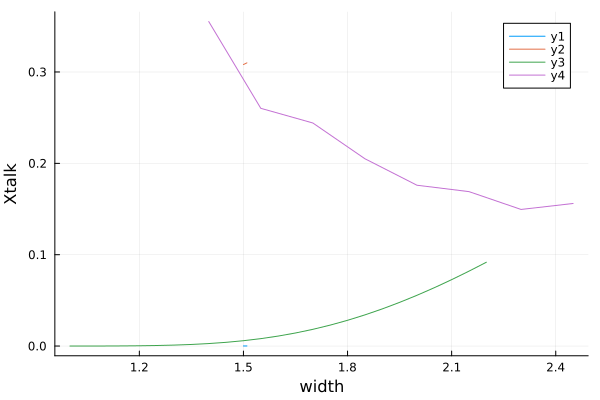

In [112]:
using Plots
plot([1.5,1.51],[r, r])
plot!([1.5, 1.51],[1.0-0.6918584335826831, 0.31])
plot!(ws, E2g, ylabel="Xtalk", xlabel="width")
plot!(1.4:0.15:2.45, 1.0 .- [0.6447810176386031, 0.739769447416722, 0.7558254360803496, 0.7949573031583098, 0.8239509472806201, 0.8309544077835114, 0.8504533000153032, 0.8439132956559842])

In [118]:
ws

1.0:0.05:2.2

In [189]:
1 - 0.9659829915306812

0.034017008469318766

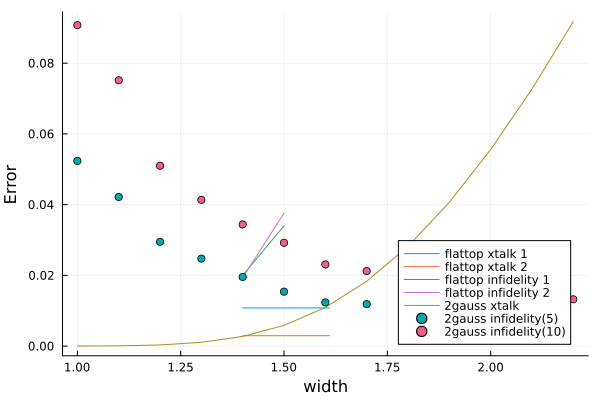

In [ ]:
using Plots
w10 = 1.0:0.1:2.2
fid10 = 1.0 .- [0.9092511140927476, 0.9248224503879527, 0.9489991720575734, 0.9586463248748862,
0.9655904867368499, 0.970780816780777, 0.9769008454986168, 0.9787819390746636,
0.9815187915434076, 0.982567600329501, 0.9846502914463217, 0.9860102138263201, 0.9867704977658038]

w5 = 1.0:0.1:1.7
fid5 = 1.0 .- [0.947633835145083, 0.9578427583457848, 0.9705031919105269, 0.9752539474085783, 0.9804641791575455, 0.9846032812727189, 0.9876492554726586, 0.9881354429808908]

w20 = 1.4:0.1:2.1
fid20 = 1.0 .- [0.9323794626692266, 0.9360347578170656, 0.9566498700911159, 0.96330640102968, 0.9629629045776062, 0.9637954044918324, 0.9668116749862175, 0.9737675981125149]

r1 = 0.0108
r2 = 0.002932
r3 = 0.00012
#plot([1.0],[0.0])
plot([1.4,1.61],[r1, r1], label="flattop xtalk 1")
plot!([1.4,1.61],[r, r], label="flattop xtalk 2")
#scatter!([1.4, 1.5, 1.6], 1.0 .- [0.980018, 0.965983, 0.938012])#, label="flattop infidelity")  #[1.0-0.9659829915306812, 1-0.9659829915306812], label="flattop infidelity")
#plot!([1.4, 1.5, 1.6], 1.0 .- [0.980018, 0.965983, 0.938012], label="flattop infidelity 1")  #[1.0-0.9659829915306812, 1-0.9659829915306812], label="flattop infidelity")
#plot!([1.4, 1.5, 1.6], 1.0 .- [0.9806337900659575, 0.9624022, 0.938804],  label="flattop infidelity 2")
plot!([1.4, 1.5], 1.0 .- [0.980018, 0.965983], label="flattop infidelity 1")  #[1.0-0.9659829915306812, 1-0.9659829915306812], label="flattop infidelity")
plot!([1.4, 1.5], 1.0 .- [0.9806337900659575, 0.9624022],  label="flattop infidelity 2")
plot!(ws, E2g, ylabel="Error", xlabel="width", label="2gauss xtalk")
scatter!(w5, fid5, label="2gauss infidelity(5)")
scatter!(w10, fid10, label="2gauss infidelity(10)")
#scatter!(w20, fid20, label="2gauss infidelity(20)")

In [122]:
a = 1 - 0.965983
b = 1 - 0.9624022
c = 1 - 0.96875
a

0.034016999999999964

In [252]:
E2g

13-element Vector{Any}:
 9.54016287307925e-6
 7.093695676441409e-5
 0.000326272453803199
 0.0010698501506999198
 0.002745041231162644
 0.00587072127573848
 0.010936767510604992
 0.018315638888734186
 0.028215008266802462
 0.040671972241088816
 0.05557621261148309
 0.07270717596764428
 0.0917736782231209

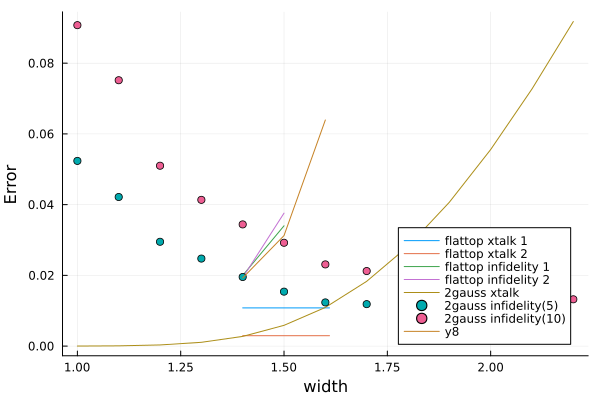

In [237]:
plot!([1.4, 1.5, 1.6], 1.0 .- [0.980724,0.96875,0.93606])

In [238]:
using BenchmarkTools

In [239]:
#@btime rec_HG_field_2d(xx[1],yy[1],zrs[1],laser_params);
#@btime E = [rec_HG_field_2d(xx[i],yy[i],zrs[i], laser_params) for i in 1:length(xx)];

In [240]:
#@btime reconstruct_HG_field_2d(xx[1],yy[1],zrs[1], Ω_w_z, c_xy) #laser_params)
#@btime E = [reconstruct_HG_field_2d(xx[i],yy[i],zrs[i], Ω_w_z, c_xy) for i in 1:length(xx)];

In [242]:
"""using GLMakie
surface(xx, yy, z, axis=(type=Axis3,))"""

"using GLMakie\nsurface(xx, yy, z, axis=(type=Axis3,))"

In [244]:
using Plots #CairoMakie
#pyplot();

In [245]:
new_x = [round(xx[i]; digits=4) for i in 1:len_x] 
new_y = [round(yy[len_x * j]; digits=4) for j in 1:(len_y)] ;

In [246]:
zx = 0.0*x_0
zy = 0.0*y_0
for j in 16:16 #0:(len_y-1) #16:16 #
    zx .+= [round(z0[len_x * j + i]; digits=4) for i in 1:len_x] #./len_y #./5.3
end
zx = zx ./maximum(zx)*1.02

for i in 15:15 #1:len_x #15:15 #
    zy .+= [round(z0[len_x * j + i]; digits=4) for j in 0:(len_y-1)] #./len_x #./5
end
zy = zy ./maximum(zy)*1.03;

In [247]:
laser_params = Dict("Ω" => 1.,"w0" => w,"z0" => 1., "θ" => 0.0, 
                "n_sg" => 1,"type" => "flattop", "coeffs_xy"=>c_xy) # [1., w, 1., 0.0]zrs = 0.0 .* xx #.+ 2.0 
#cxy = 1.05 * c_xy
E_rec = []
for i in 1:length(xx)
    push!(E_rec, real.(reconstruct_HG_field_2d(xx[i],yy[i],zrs[i],  Ω_w_z, c_xy))); #reconstruct_HG_field_2d;
end;
E_rec;

In [248]:
y_mid = 16
Fx_rec = [round(E_rec[len_x * y_mid + i]; digits=4) for i in 1:len_x] 
Fx_rec = Fx_rec #./ maximum(Fx_rec) * 1.02

x_mid = 15
Fy_rec = [round(E_rec[len_x * j + x_mid]; digits=4) for j in 0:(len_y-1)] 
Fy_rec = Fy_rec; #./ maximum(Fy_rec) * 1.03  ; 

In [249]:
minimum(zx)

-0.24773745843573805

In [250]:
minimum(zy)

-0.04338959408564654

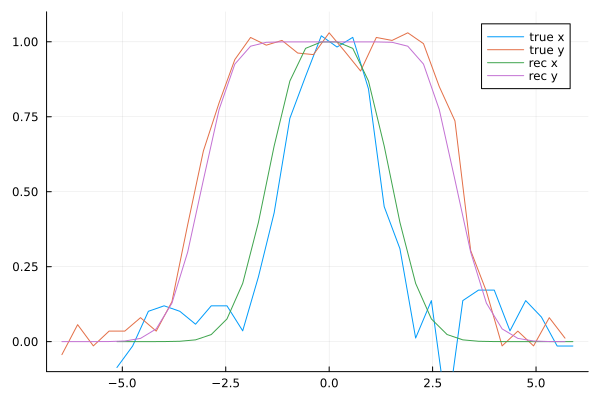

In [251]:
using Plots 

plot(new_x, zx, label="true x", ylims=(-0.1,1.1))
plot!(new_y, zy, label="true y")
plot!(new_x, Fx_rec, label="rec x")
plot!(new_y, Fy_rec, label="rec y")
#plot!(new_x, exp.(-new_x.^2 ./ 2.2^2))